<Figure size 1000x600 with 0 Axes>

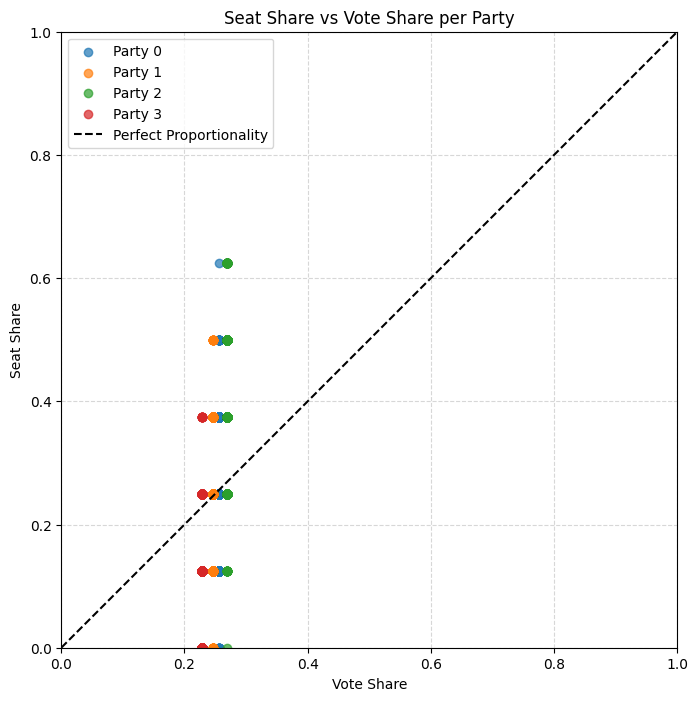


----- REDISTRICTING SUMMARY -----
Runs: 1000
Party 0: Mean Vote Share = 0.256, Mean Seat Share = 0.251
Party 1: Mean Vote Share = 0.246, Mean Seat Share = 0.233
Party 2: Mean Vote Share = 0.269, Mean Seat Share = 0.407
Party 3: Mean Vote Share = 0.229, Mean Seat Share = 0.109


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import copy
import math



# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000       # Can change
NUM_PARTIES = 4       # Can change
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 1000           # Number of redistricting simulations

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------
voter_parties = np.random.randint(0, NUM_PARTIES, NUM_VOTERS)
voter_colors = party_colors[voter_parties]
def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    # Create districts with BFS
    for d in range(num_districts):
        if not unassigned:
            break

        seed = np.random.choice(list(unassigned))
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        # Retry if district incomplete
        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district)

    # ------------------------
    # Assign leftover voters to nearest district
    # ------------------------
    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district
# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

def efficiency_gap(district_counts):
    """
    Returns a list of efficiency gap values,
    one per district (for a single run).
    """

    district_gaps = []

    for district in district_counts:

        # Winning party
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]

        # Total votes in district
        total_votes = sum(district.values())

        # Losing votes
        num_losing_votes = total_votes - num_winning_votes

        # Wasted votes (multi-party generalization)
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes

        gap = (wasted_winner - wasted_loser) / total_votes

        district_gaps.append(gap)

    return district_gaps

'''# ------------------------
# EFFICIENCY GAP (2-party only)
# ------------------------
def efficiency_gap(district_counts):
    if NUM_PARTIES != 2:
        return None
    wasted = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for d in district_counts:
        total = sum(d.values())
        total_votes += total
        winner = max(d, key=d.get)
        for party in PARTY_IDS:
            if party == winner:
                wasted[party] += d[party] - total / 2
            else:
                wasted[party] += d[party]

    return (wasted[PARTY_IDS[0]] - wasted[PARTY_IDS[1]]) / total_votes
'''
def get_is_winner(district_counts, target_party):
    """
    Returns True if target_party has more votes than all others.
    If there is any tie for the maximum, the target party loses.
    """
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    
    # Target must be strictly greater than every other party
    return all(target_votes > v for v in other_votes)

def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # Best effort: move 1 vote from each competitor to target
            moved = 0
            for p in competitors:
                if d[p] > 0:
                    d[p] -= 1
                    moved += 1
            if moved > 0:
                d[target_party] += moved
                any_shift = True
        
        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == NUM_DISTRICTS:
            break
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0} # Share calculated externally

def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # Best effort: move up to (n-1) votes away from target
            to_remove = min(d[target_party], num_competitors)
            if to_remove > 0:
                d[target_party] -= to_remove
                # Distribute those votes one by one to competitors
                for i in range(to_remove):
                    d[competitors[i % num_competitors]] += 1
                any_shift = True
        
        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == 0:
            break
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


# 1. Update your simulation functions to return the current vote share
def get_current_vote_share(district_counts, target_party):
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

# 2. Updated compute function
def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    # Calculate starting state
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))
    
    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    # Base point is the current status of the party
    base_point = (initial_vote, initial_wins)

    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged
#3. Updated plotting function to show both curves
def plot_step_and_complement(step_points, NUM_DISTRICTS, title="Seat–Vote Curve"):
    x, y = zip(*sorted(step_points))
    x, y = np.array(x), np.array(y)

    # Convert district counts to seat share (0–1)
    y = y / NUM_DISTRICTS

    plt.figure(figsize=(8, 6))
    
    # Original curve
    plt.step(x, y, where="post", color="black", label="Seat–Vote Curve", lw=2)

    # Complement curve: (1-x, 1-y)
    xc = 1 - x
    yc = 1 - y
    
    # Sort for proper plotting
    order = np.argsort(xc)
    plt.step(xc[order], yc[order], where="post",
             color="blue", linestyle="--", label="Complement Curve")

    plt.xlabel("Statewide Vote Share")
    plt.ylabel("Seat Share")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()    

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat–vote curve (as seat share 0–1)
    and its complement curve.

    Parameters:
        step_points: list of (vote_share, districts_won) tuples
        num_districts: total number of districts

    Returns:
        Dictionary with:
            - area_between
            - area_step
            - area_complement
    """
    # Sort points by vote share
    points = sorted(step_points, key=lambda x: x[0])
    
    # Ensure endpoints at 0 and 1
    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]
    
    # Convert to numpy arrays
    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts   # Normalize to 0–1 seat share

    # Complement curve: g(x) = 1 - f(1-x)
    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]

    # Combine all x-breakpoints
    all_x = np.unique(np.concatenate([step_x, complement_x]))
    
    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        idx = max(0, idx)
        return ys[idx]

    for i in range(len(all_x) - 1):
        x1 = all_x[i]
        x2 = all_x[i + 1]
        width = x2 - x1

        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)

        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }
# ------------------------
# RUN SIMULATIONS
# ------------------------
all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []       # Party 0 only, optional
all_seat_shares = []       # Party 0 only, optional
all_pr_vote_shares = []    # dict of all parties
all_pr_seat_shares = []    # dict of all parties
all_district_counts = []    # For potential further analysis
all_area_results = []    # For step function area analysis
all_step_curves = []       # Store step curves for potential plotting
plt.figure(figsize=(10,6))

for run in range(NUM_RUNS):
    district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)
    district_counts = count_votes(district_labels)

    # Efficiency gap
    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    # ------------------------
    # Proportional Representation (all parties)
    # ------------------------
    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    # Normalize vote share
    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    # Seat share
    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)
    # -----------------------------------------
# STEP CURVES FOR EACH PARTY (per simulation)
# -----------------------------------------

    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts,
            party,
            PARTY_IDS,
            NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_metrics = compute_step_function_area(curve, NUM_DISTRICTS)
        area_results_this_run[party] = area_metrics

# Store all curves for this simulation
    all_step_curves.append(step_curves_this_run)
    all_area_results.append(area_results_this_run)



# ------------------------
# SCATTER PLOT: Vote Share vs Seat Share
# ------------------------
plt.figure(figsize=(8,8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0,1],[0,1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ------------------------
# SUMMARY
# ------------------------
print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")

    

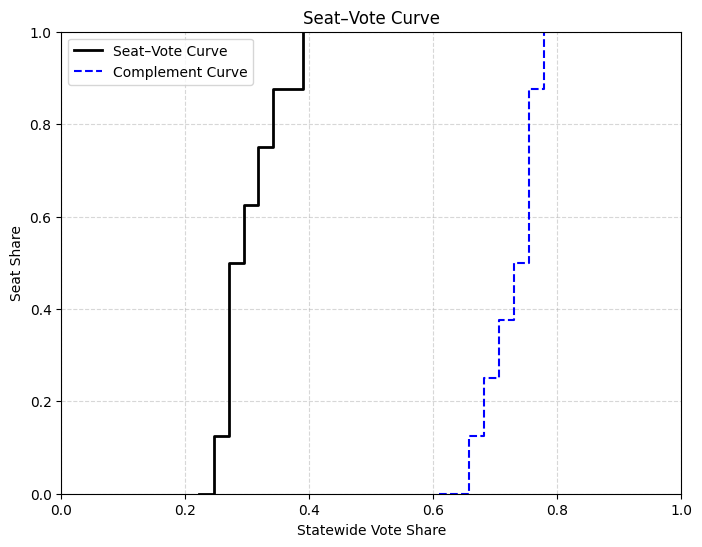

Area Step: 0.7
Area Complement: 0.273
Area Difference (Bias): 0.42699999999999994
[[-0.626, -0.674, -0.706, -0.706, -0.562, -0.642, -0.69, -0.642], [-0.706, -0.626, -0.706, -0.626, -0.658, -0.69, -0.658, -0.674], [-0.674, -0.674, -0.626, -0.658, -0.69, -0.674, -0.706, -0.674], [-0.69, -0.69, -0.658, -0.674, -0.562, -0.722, -0.642, -0.69], [-0.69, -0.706, -0.69, -0.69, -0.69, -0.706, -0.658, -0.69], [-0.706, -0.706, -0.626, -0.642, -0.706, -0.642, -0.706, -0.61], [-0.706, -0.626, -0.658, -0.61, -0.69, -0.674, -0.722, -0.642], [-0.642, -0.594, -0.706, -0.69, -0.658, -0.642, -0.69, -0.642], [-0.674, -0.706, -0.674, -0.642, -0.642, -0.706, -0.674, -0.642], [-0.658, -0.61, -0.706, -0.69, -0.658, -0.706, -0.626, -0.674], [-0.642, -0.722, -0.722, -0.706, -0.61, -0.69, -0.642, -0.658], [-0.594, -0.706, -0.642, -0.674, -0.69, -0.69, -0.69, -0.706], [-0.642, -0.69, -0.69, -0.626, -0.69, -0.674, -0.658, -0.706], [-0.674, -0.658, -0.706, -0.626, -0.658, -0.706, -0.69, -0.61], [-0.642, -0.69, -0.69

-0.69

In [35]:
plot_step_and_complement(all_step_curves[0]["Party 1"], NUM_DISTRICTS)
# Access the dictionary for the first run, then the specific party
party_0_run_0_metrics = all_area_results[0]["Party 1"]

# Now you can print individual components
print("Area Step:", party_0_run_0_metrics["area_step"])
print("Area Complement:", party_0_run_0_metrics["area_complement"])
print("Area Difference (Bias):", party_0_run_0_metrics["area_between"])


print(all_efficiency_gaps)
all_efficiency_gaps[2][4]

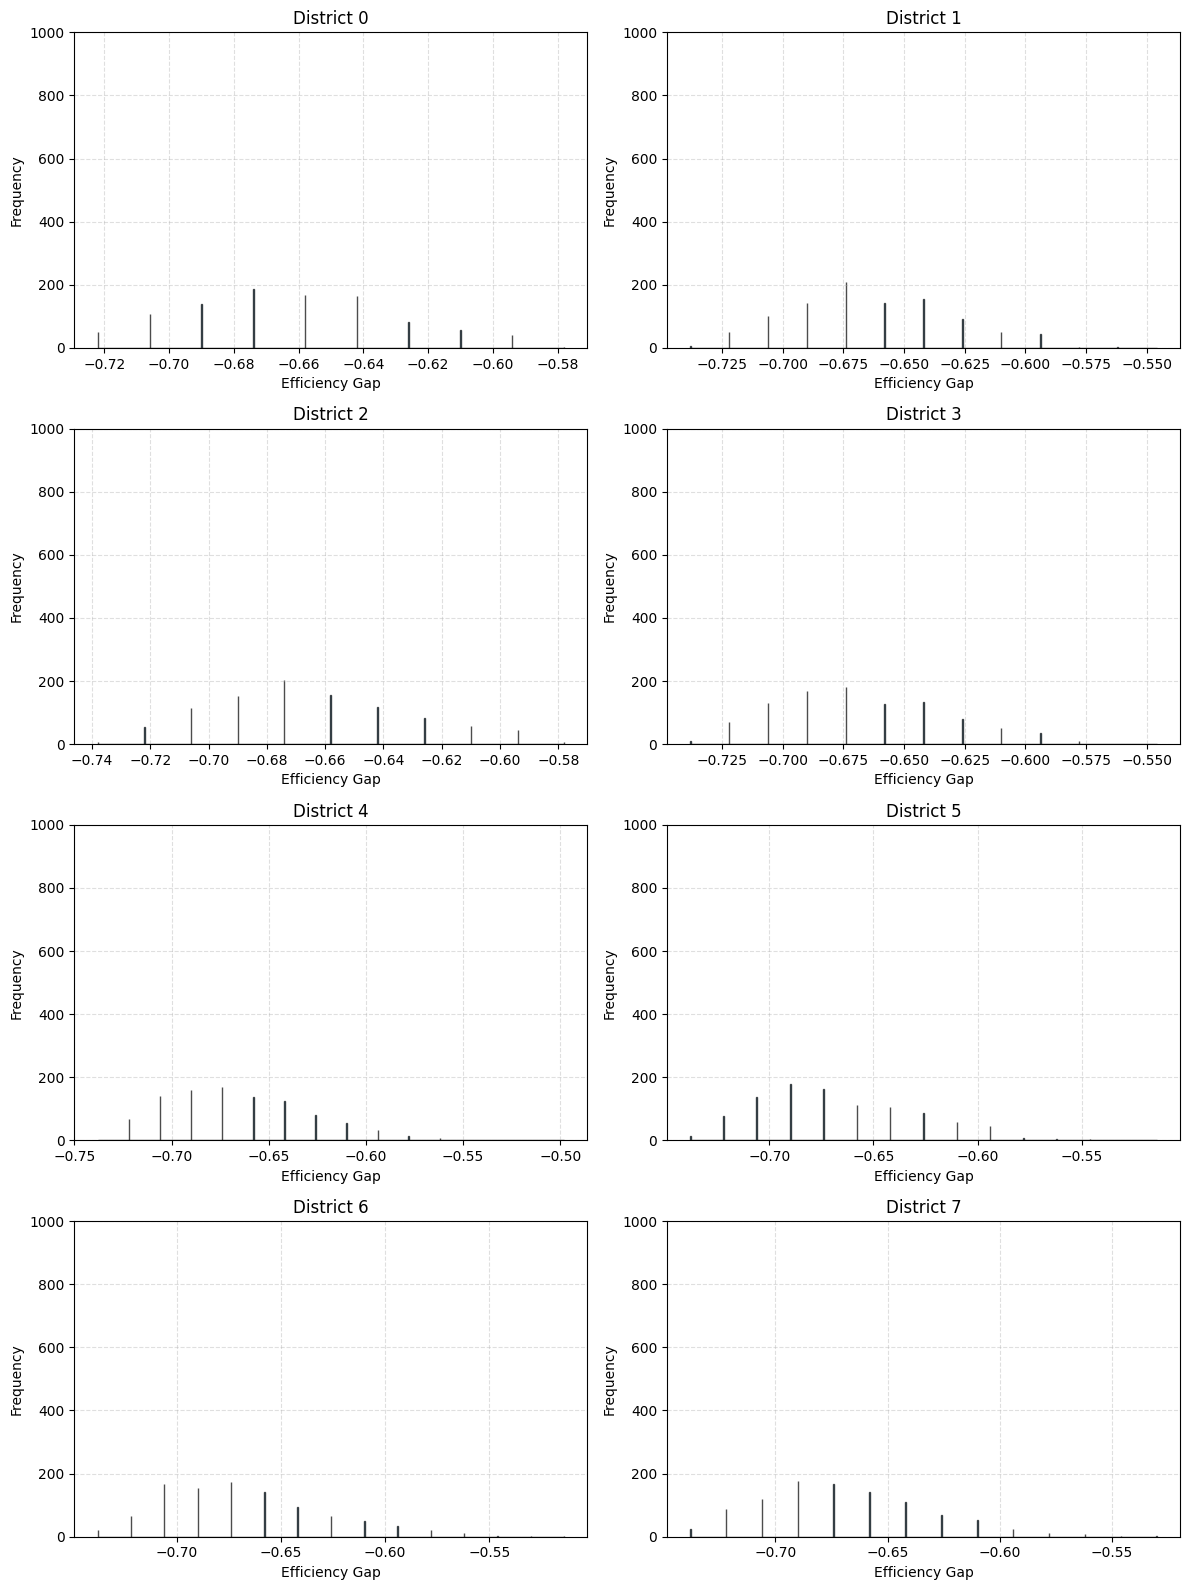

In [36]:
import matplotlib.pyplot as plt

import numpy as np

#Efficiency Gap Histograms per District

# Number of districts
n_districts = NUM_DISTRICTS

# Grid layout
n_cols = 2
n_rows = math.ceil(n_districts / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

# Plot histograms
for d in range(n_districts):
    district_gaps = [all_efficiency_gaps[run][d] for run in range(NUM_RUNS)]
    
    axes[d].hist(district_gaps, bins=NUM_RUNS, edgecolor='black', alpha=0.7)
    axes[d].set_title(f"District {d}")
    axes[d].set_xlabel("Efficiency Gap")
    axes[d].set_ylabel("Frequency")
    axes[d].set_ylim(0, NUM_RUNS)  # FIXED vertical axis
    axes[d].grid(True, linestyle="--", alpha=0.4)

# Remove empty subplots
for j in range(d+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

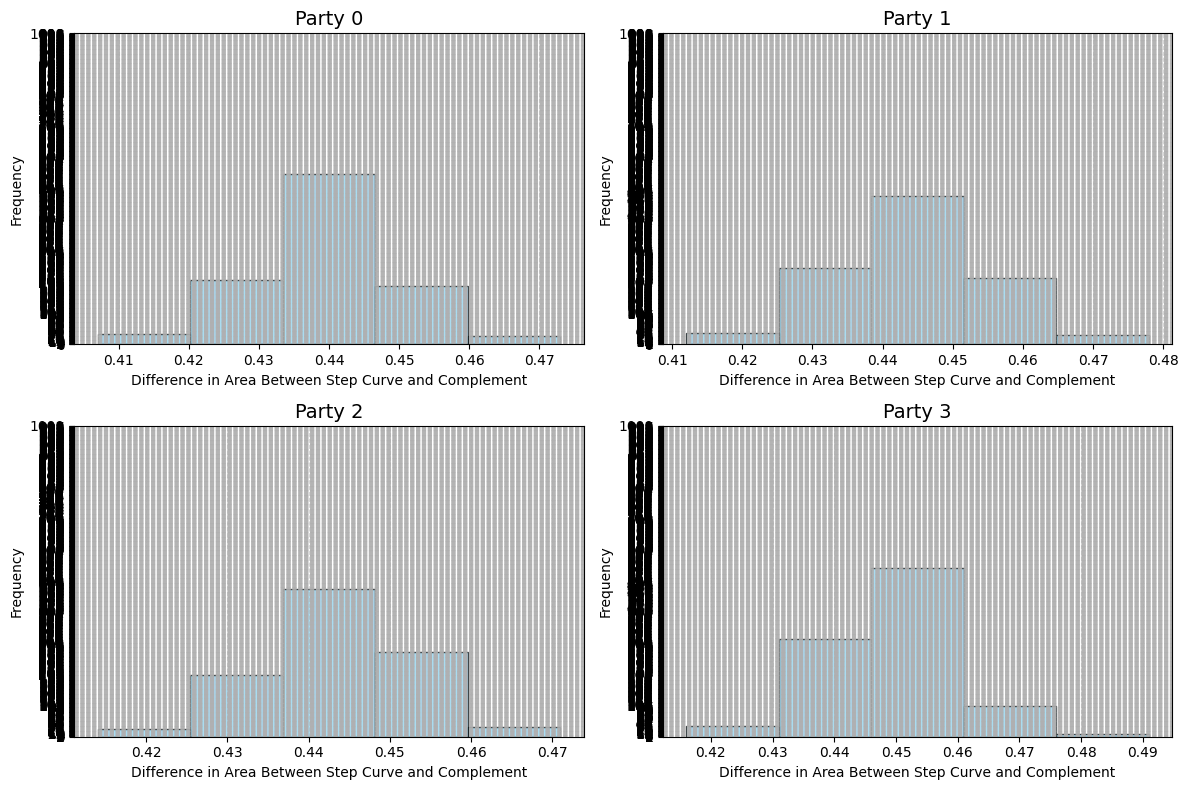

In [37]:

# ------------------------
# Grid layout
# ------------------------
n_parties = len(PARTY_IDS)
n_cols = 2  # number of columns in the grid
n_rows = math.ceil(n_parties / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()  # flatten so we can index easily

# ------------------------
# Plot histograms per party
# ------------------------
for i, party in enumerate(PARTY_IDS):
    # Collect area_between values for this party across all simulations
    area_differences = [
        area_results_this_run[party]["area_between"]
        for area_results_this_run in all_area_results
        if party in area_results_this_run
    ]
    
    # Use larger bins, e.g., 5 or 'auto'
    axes[i].hist(area_differences, bins=5, alpha=0.7, color='skyblue', edgecolor='black', density=False)
    
    axes[i].set_title(f"{party}", fontsize=14)
    axes[i].set_xlabel("Difference in Area Between Step Curve and Complement")
    axes[i].set_ylabel("Frequency")
    axes[i].set_ylim(0, NUM_RUNS)  # FIXED y-axis
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].set_yticks(range(0, NUM_RUNS+1))  # integer counts

# Hide any extra subplots if n_parties is not a multiple of n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [38]:
print(all_efficiency_gaps) 
print(all_seat_counts)
print(all_vote_shares)      
print(all_seat_shares)        # Party 0 only, optional
print(all_pr_vote_shares)     # dict of all parties
print(all_pr_seat_shares)     # dict of all parties
print(all_district_counts)     # For potential further analysis
print(all_area_results)     # For step function area analysis
print(all_step_curves) 


[[-0.626, -0.674, -0.706, -0.706, -0.562, -0.642, -0.69, -0.642], [-0.706, -0.626, -0.706, -0.626, -0.658, -0.69, -0.658, -0.674], [-0.674, -0.674, -0.626, -0.658, -0.69, -0.674, -0.706, -0.674], [-0.69, -0.69, -0.658, -0.674, -0.562, -0.722, -0.642, -0.69], [-0.69, -0.706, -0.69, -0.69, -0.69, -0.706, -0.658, -0.69], [-0.706, -0.706, -0.626, -0.642, -0.706, -0.642, -0.706, -0.61], [-0.706, -0.626, -0.658, -0.61, -0.69, -0.674, -0.722, -0.642], [-0.642, -0.594, -0.706, -0.69, -0.658, -0.642, -0.69, -0.642], [-0.674, -0.706, -0.674, -0.642, -0.642, -0.706, -0.674, -0.642], [-0.658, -0.61, -0.706, -0.69, -0.658, -0.706, -0.626, -0.674], [-0.642, -0.722, -0.722, -0.706, -0.61, -0.69, -0.642, -0.658], [-0.594, -0.706, -0.642, -0.674, -0.69, -0.69, -0.69, -0.706], [-0.642, -0.69, -0.69, -0.626, -0.69, -0.674, -0.658, -0.706], [-0.674, -0.658, -0.706, -0.626, -0.658, -0.706, -0.69, -0.61], [-0.642, -0.69, -0.69, -0.658, -0.61, -0.642, -0.562, -0.706], [-0.594, -0.674, -0.658, -0.674, -0.642,

In [39]:
# ------------------------
# Convert to DataFrame for better visualization 

import pandas as pd

# all_efficiency_gaps is currently [run][district]

# Convert to DataFrame: rows=districts, columns=runs
df_efficiency = pd.DataFrame(all_efficiency_gaps).T

# Rename columns for clarity
df_efficiency.columns = [f"Run {i}" for i in range(NUM_RUNS)]
df_efficiency.index = [f"District {i}" for i in range(NUM_DISTRICTS)]

# Display
print(df_efficiency)



            Run 0  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  \
District 0 -0.626 -0.706 -0.674 -0.690 -0.690 -0.706 -0.706 -0.642 -0.674   
District 1 -0.674 -0.626 -0.674 -0.690 -0.706 -0.706 -0.626 -0.594 -0.706   
District 2 -0.706 -0.706 -0.626 -0.658 -0.690 -0.626 -0.658 -0.706 -0.674   
District 3 -0.706 -0.626 -0.658 -0.674 -0.690 -0.642 -0.610 -0.690 -0.642   
District 4 -0.562 -0.658 -0.690 -0.562 -0.690 -0.706 -0.690 -0.658 -0.642   
District 5 -0.642 -0.690 -0.674 -0.722 -0.706 -0.642 -0.674 -0.642 -0.706   
District 6 -0.690 -0.658 -0.706 -0.642 -0.658 -0.706 -0.722 -0.690 -0.674   
District 7 -0.642 -0.674 -0.674 -0.690 -0.690 -0.610 -0.642 -0.642 -0.642   

            Run 9  ...  Run 990  Run 991  Run 992  Run 993  Run 994  Run 995  \
District 0 -0.658  ...   -0.690   -0.674   -0.594   -0.674   -0.594   -0.642   
District 1 -0.610  ...   -0.674   -0.690   -0.642   -0.690   -0.642   -0.642   
District 2 -0.706  ...   -0.722   -0.610   -0.674   -0.642   -0.67

In [40]:
table_data = { "Party": PARTY_IDS}

for run_idx in range(NUM_RUNS):
    column_name = f"Run {run_idx+1}"
    run_values = []

    for party in PARTY_IDS:
      area_val = all_area_results[run_idx][party]["area_between"]
      run_values.append(f"{area_val:.4f}")
    
    table_data[column_name] = run_values

df_runs = pd.DataFrame(table_data)
print("\n--- AREA DIFFERENCE PER SIMULATION ---")
print(df_runs.to_string(index=False))


--- AREA DIFFERENCE PER SIMULATION ---
  Party  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9 Run 10 Run 11 Run 12 Run 13 Run 14 Run 15 Run 16 Run 17 Run 18 Run 19 Run 20 Run 21 Run 22 Run 23 Run 24 Run 25 Run 26 Run 27 Run 28 Run 29 Run 30 Run 31 Run 32 Run 33 Run 34 Run 35 Run 36 Run 37 Run 38 Run 39 Run 40 Run 41 Run 42 Run 43 Run 44 Run 45 Run 46 Run 47 Run 48 Run 49 Run 50 Run 51 Run 52 Run 53 Run 54 Run 55 Run 56 Run 57 Run 58 Run 59 Run 60 Run 61 Run 62 Run 63 Run 64 Run 65 Run 66 Run 67 Run 68 Run 69 Run 70 Run 71 Run 72 Run 73 Run 74 Run 75 Run 76 Run 77 Run 78 Run 79 Run 80 Run 81 Run 82 Run 83 Run 84 Run 85 Run 86 Run 87 Run 88 Run 89 Run 90 Run 91 Run 92 Run 93 Run 94 Run 95 Run 96 Run 97 Run 98 Run 99 Run 100 Run 101 Run 102 Run 103 Run 104 Run 105 Run 106 Run 107 Run 108 Run 109 Run 110 Run 111 Run 112 Run 113 Run 114 Run 115 Run 116 Run 117 Run 118 Run 119 Run 120 Run 121 Run 122 Run 123 Run 124 Run 125 Run 126 Run 127 Run 128 Run 129 Run 130 Run 131 Run

In [41]:
district_counts 

[{'Party 0': 26, 'Party 1': 29, 'Party 2': 36, 'Party 3': 34},
 {'Party 0': 41, 'Party 1': 26, 'Party 2': 33, 'Party 3': 25},
 {'Party 0': 32, 'Party 1': 30, 'Party 2': 33, 'Party 3': 30},
 {'Party 0': 27, 'Party 1': 38, 'Party 2': 28, 'Party 3': 32},
 {'Party 0': 31, 'Party 1': 36, 'Party 2': 33, 'Party 3': 25},
 {'Party 0': 34, 'Party 1': 28, 'Party 2': 37, 'Party 3': 26},
 {'Party 0': 31, 'Party 1': 28, 'Party 2': 32, 'Party 3': 34},
 {'Party 0': 34, 'Party 1': 31, 'Party 2': 37, 'Party 3': 23}]

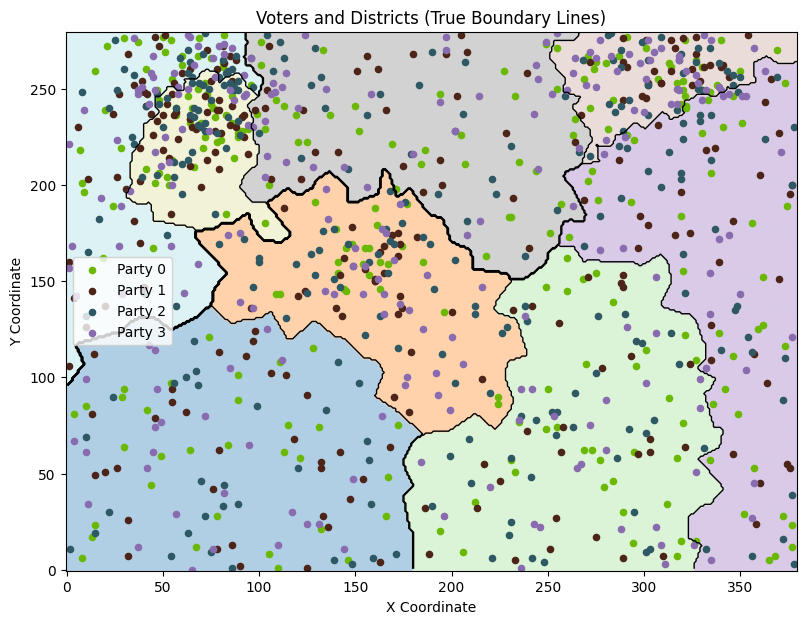

In [42]:
# ------------------------
# VISUALIZE ONE RUN (NO OVERLAP)
# ------------------------

district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)

# Build KD-tree for fast nearest lookup
tree = cKDTree(voters)

# Create grid of every pixel
xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Assign each pixel to nearest voter
_, nearest_voter = tree.query(grid_points)
pixel_districts = district_labels[nearest_voter]
pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

plt.figure(figsize=(10,7))

# Lightly color districts
plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)

# Draw district boundaries
plt.contour(
    pixel_map,
    levels=np.arange(NUM_DISTRICTS)+0.5,
    colors='black',
    linewidths=1,
    origin='lower'
)

# Plot voters on top
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(
        voters[mask,0],
        voters[mask,1],
        color=PARTY_COLORS[party],
        label=party,
        s=20
    )

plt.title("Voters and Districts (True Boundary Lines)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

